# Practical 05: Neural Network Regression (Boston Housing)

## Dataset: Boston Housing Dataset
## Subject: Machine Learning

Objective: Predict house prices using a Neural Network model.


## Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense

## Load Dataset

In [4]:
data = pd.read_csv("BostonHousing.csv")
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## Feature and Target Split

In [5]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

## Feature Scaling

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## Build Neural Network Model

In [8]:
model = Sequential()

model.add(Dense(50, activation='relu', input_dim=13))
model.add(Dense(50, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [9]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

## Train Model

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 606.7889 - mae: 22.6045 - val_loss: 537.9999 - val_mae: 21.5743
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 568.7411 - mae: 21.6985 - val_loss: 497.9271 - val_mae: 20.6114
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 519.1351 - mae: 20.5037 - val_loss: 440.3742 - val_mae: 19.1400
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 445.2788 - mae: 18.6130 - val_loss: 357.0333 - val_mae: 16.8635
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 342.5168 - mae: 15.8070 - val_loss: 247.7503 - val_mae: 13.6480
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 219.6269 - mae: 12.2388 - val_loss: 136.3302 - val_mae: 9.4726
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 123.2338 - mae: 9.0980 - val_loss: 67.1506 - val_mae: 6.1309
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 80.4801 - mae: 7.1152 - val_loss: 48.3424 - val_mae: 5.1022
Epoch 9/100
10/10 ━━━━

## Model Evaluation

In [11]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Mean Absolute Error:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11.9206 - mae: 2.2057
Test Loss: 11.920580863952637
Mean Absolute Error: 2.205700397491455


## Visualization: Loss vs Epochs

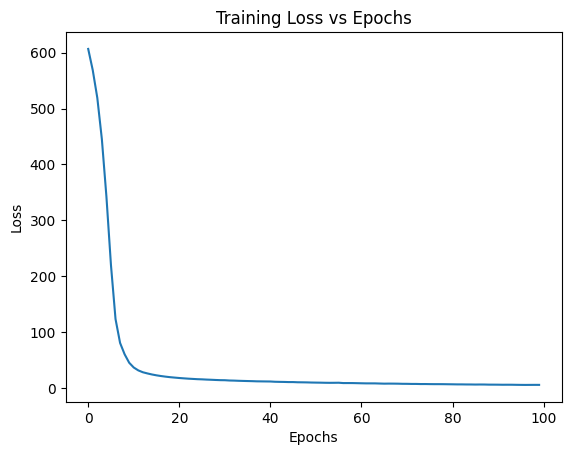

In [12]:
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.show()

## Visualization: Training vs Validation Loss

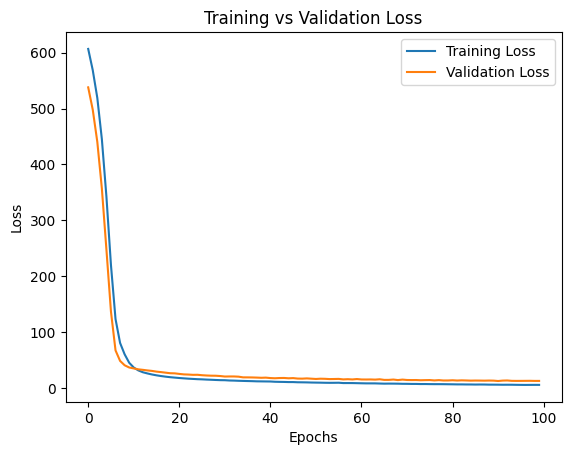

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss','Validation Loss'])
plt.title("Training vs Validation Loss")
plt.show()

## Conclusion

A Neural Network model was successfully implemented for regression. The model learned complex relationships in the dataset and achieved reasonable prediction accuracy. Loss curves indicated effective training and convergence.